Project 2: Customer Segmentation Analysis using K-Means Clustering

In [18]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [19]:
# Load the Dataset

df = pd.read_csv("Mall_Customers.csv")

In [20]:
# Display First 5 Rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [21]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [22]:
# Statistical Summary

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [23]:
# Check Missing Values

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [24]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [25]:
# Display Column Names

df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

1. Gender Distribution

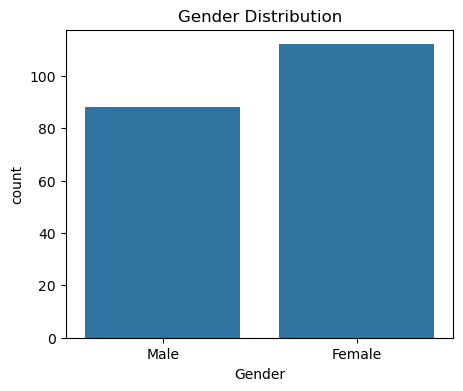

In [26]:
# Gender Distribution

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.show()

2. Age Distribution

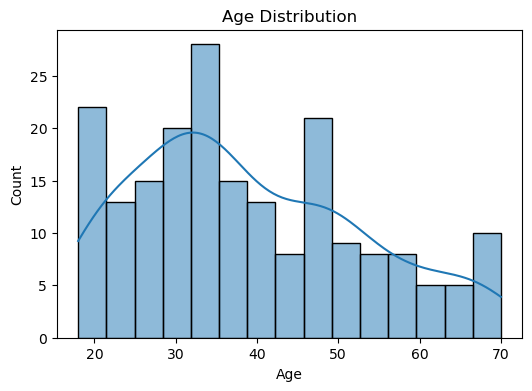

In [27]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

3. Annual Income Distribution

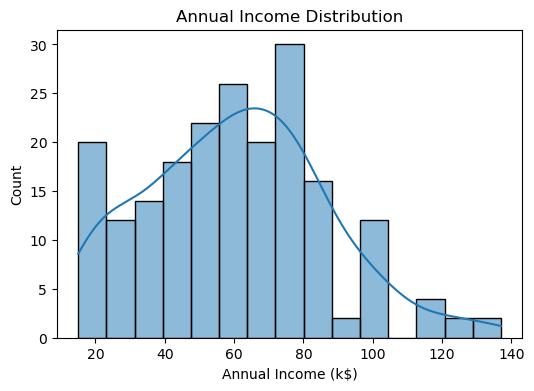

In [28]:
# Annual Income Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.show()

4. Spending Score Distribution

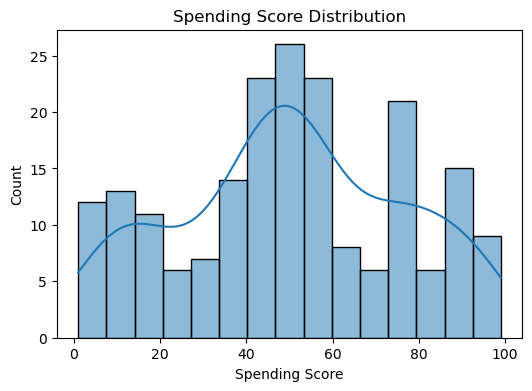

In [29]:
# Spending Score Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.show()

5. Annual Income vs Spending Score

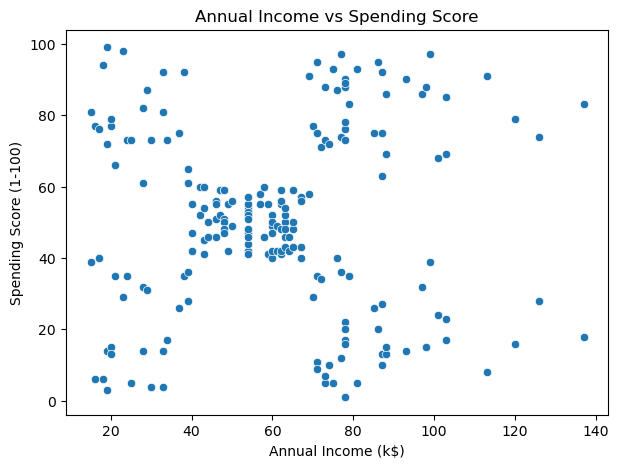

In [30]:
# Annual Income vs Spending Score

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")

plt.show()

6. Elbow Method

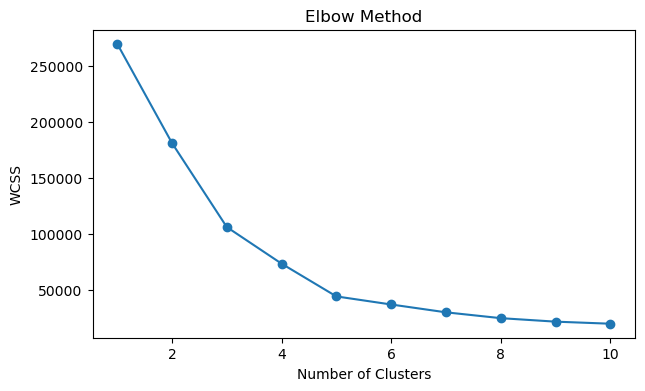

In [31]:
# Elbow Method

X = df.iloc[:, [3,4]]

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

7. Apply K-Means Clustering

In [32]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


8. Customer Segments Visualization

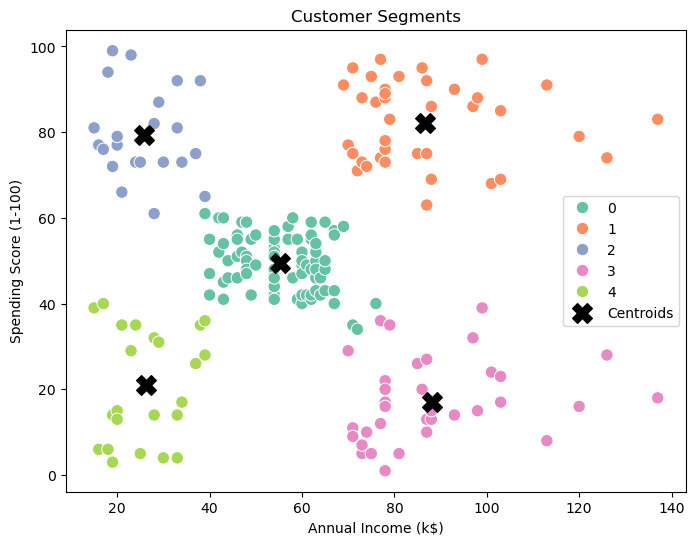

In [33]:
# Customer Segments Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="black",
    s=200,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments")
plt.legend()

plt.show()

In [34]:
# Cluster Count

df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [35]:
# Average Values by Cluster

df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [36]:
# Save Dataset with Cluster Labels

df.to_csv("Mall_Customers_Clustered.csv", index=False)

# Conclusion

- The dataset was successfully analyzed using customer segmentation techniques.
- No missing values or duplicate records were found in the dataset.
- The Elbow Method was used to determine the optimal number of clusters.
- K-Means Clustering grouped customers into different segments based on Annual Income and Spending Score.
- The identified customer segments can help businesses improve marketing strategies and customer targeting.
- This analysis provides valuable insights for understanding customer behavior and supporting business decisions.